In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
x,y= make_regression(n_samples= 100, n_features= 2, n_targets= 1, n_informative= 2, noise= 50)

In [7]:
y= y.reshape(-1, 1)
y

array([[ -16.14840823],
       [   1.3442948 ],
       [-127.87803923],
       [ 121.98859941],
       [  81.74921262],
       [  26.04530714],
       [-166.69949803],
       [ -58.66543471],
       [ -77.92512675],
       [  14.45353929],
       [  94.33905118],
       [   9.36634747],
       [  60.6258771 ],
       [ 141.51084906],
       [ -25.39508734],
       [  68.56863114],
       [ -27.17021144],
       [-128.54551146],
       [  44.74058512],
       [   3.07190442],
       [ -90.84015995],
       [-172.7031735 ],
       [  12.17138198],
       [   8.18407956],
       [ -70.4166086 ],
       [  90.30569145],
       [  79.37712173],
       [  19.63201028],
       [  89.81065247],
       [ -50.15869616],
       [ -28.24292936],
       [  20.48825598],
       [ -21.16630879],
       [  90.36280289],
       [ -13.06356315],
       [-164.62614384],
       [  14.64427236],
       [ -78.86602132],
       [  26.85691966],
       [-145.87558663],
       [ -87.30224347],
       [-143.931

In [10]:
x

array([[ 1.45695667, -0.92364537],
       [ 0.71638063,  0.08949801],
       [-1.2455377 , -2.08982835],
       [ 0.91732563,  0.75702099],
       [ 0.32199962,  1.10820247],
       [-1.04931801,  0.09074768],
       [-1.41840512,  0.1725682 ],
       [-1.14164713, -0.18703148],
       [-1.6720812 , -0.61168341],
       [ 0.30171161,  0.21096541],
       [-0.26586205,  1.57020157],
       [ 0.1616136 , -0.44521463],
       [ 0.34488619, -0.08266707],
       [-0.56845983,  0.90170216],
       [ 1.11446576, -0.91920219],
       [-0.74644217,  0.23851215],
       [-0.7237936 , -0.62560015],
       [-0.63390534,  0.21429627],
       [ 1.22663521, -1.49317261],
       [-0.45591582,  1.40554048],
       [-2.05124648,  1.12791275],
       [-0.76438141, -1.86712716],
       [ 1.44955748, -0.24538371],
       [ 0.62470487, -0.0118629 ],
       [-0.54057305,  0.55168992],
       [-0.01087106,  1.35593173],
       [ 1.48893265,  1.24166722],
       [-0.43983051, -0.19267636],
       [ 1.77092892,

In [8]:
df= pd.DataFrame(np.concatenate((x, y), axis= 1), columns= ['x1', 'x2', 'y'])

In [9]:
df.head()

,x1,x2,y
0,1.456957,-0.923645,-16.148408
1,0.716381,0.089498,1.344295
2,-1.245538,-2.089828,-127.878039
3,0.917326,0.757021,121.988599
4,0.322000,1.108202,81.749213


In [12]:
# for the 3d plot between them
px.scatter_3d(x= df['x1'], y=df['x2'], z=df['y'])

In [29]:
x_train, x_test, y_train, y_test= train_test_split(df.iloc[:, :-1], df['y'], random_state= 42, train_size= 0.8)

In [30]:
model= LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred= model.predict(x_test)
y_pred

array([  18.52136769,    1.7670684 ,   29.23329401,  -37.98290303,
         50.32960308, -100.17920314,   53.6266644 ,   23.19096151,
         36.69554916,   33.22307078,    6.10966655,   -4.92172274,
        -28.84826626,    3.26596256,  -31.07869444,   47.39028003,
         39.36011146,  -70.11139605,   11.98386182,   44.3460281 ])

In [37]:
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

def metrices(y_pred):
    return (mean_absolute_error(y_true= y_test, y_pred= y_pred),mean_squared_error(y_true= y_test, y_pred= y_pred),r2_score(y_true= y_test, y_pred= y_pred))

In [40]:
mae, mse, r2= metrices(y_pred)

In [39]:
for x in  metrices(y_pred):
    print(x)

39.80106651256737
2097.57887033295
0.5067258433251864


In [42]:
mse

2097.57887033295

<Axes: >

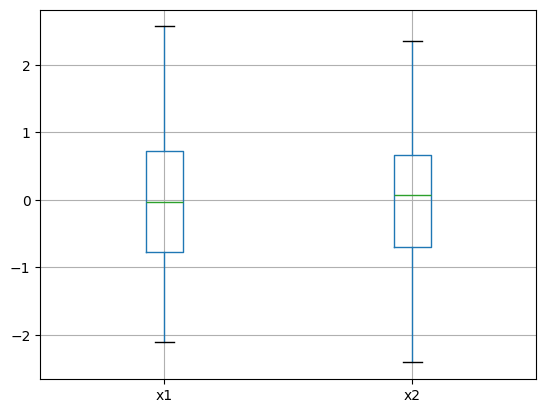

In [43]:
df[['x1', 'x2']].boxplot()

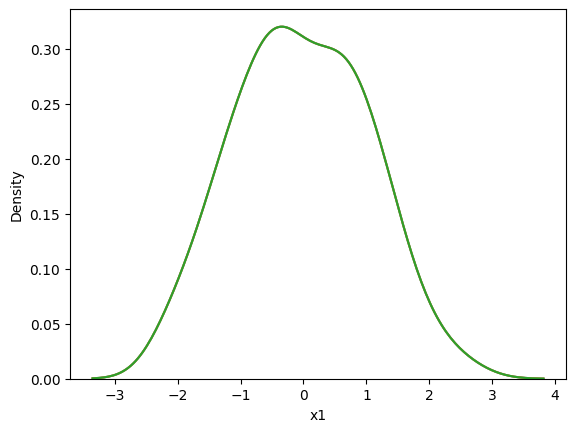

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(df['x1'])
plt.show()


In [47]:
df['x1'].skew()

np.float64(0.0690377757300496)

In [ ]:
model.coef_   #value of b1 and b2

array([42.19587908, 30.54250343])

In [ ]:
model.intercept_  #value of b0

np.float64(-0.044054965844877)